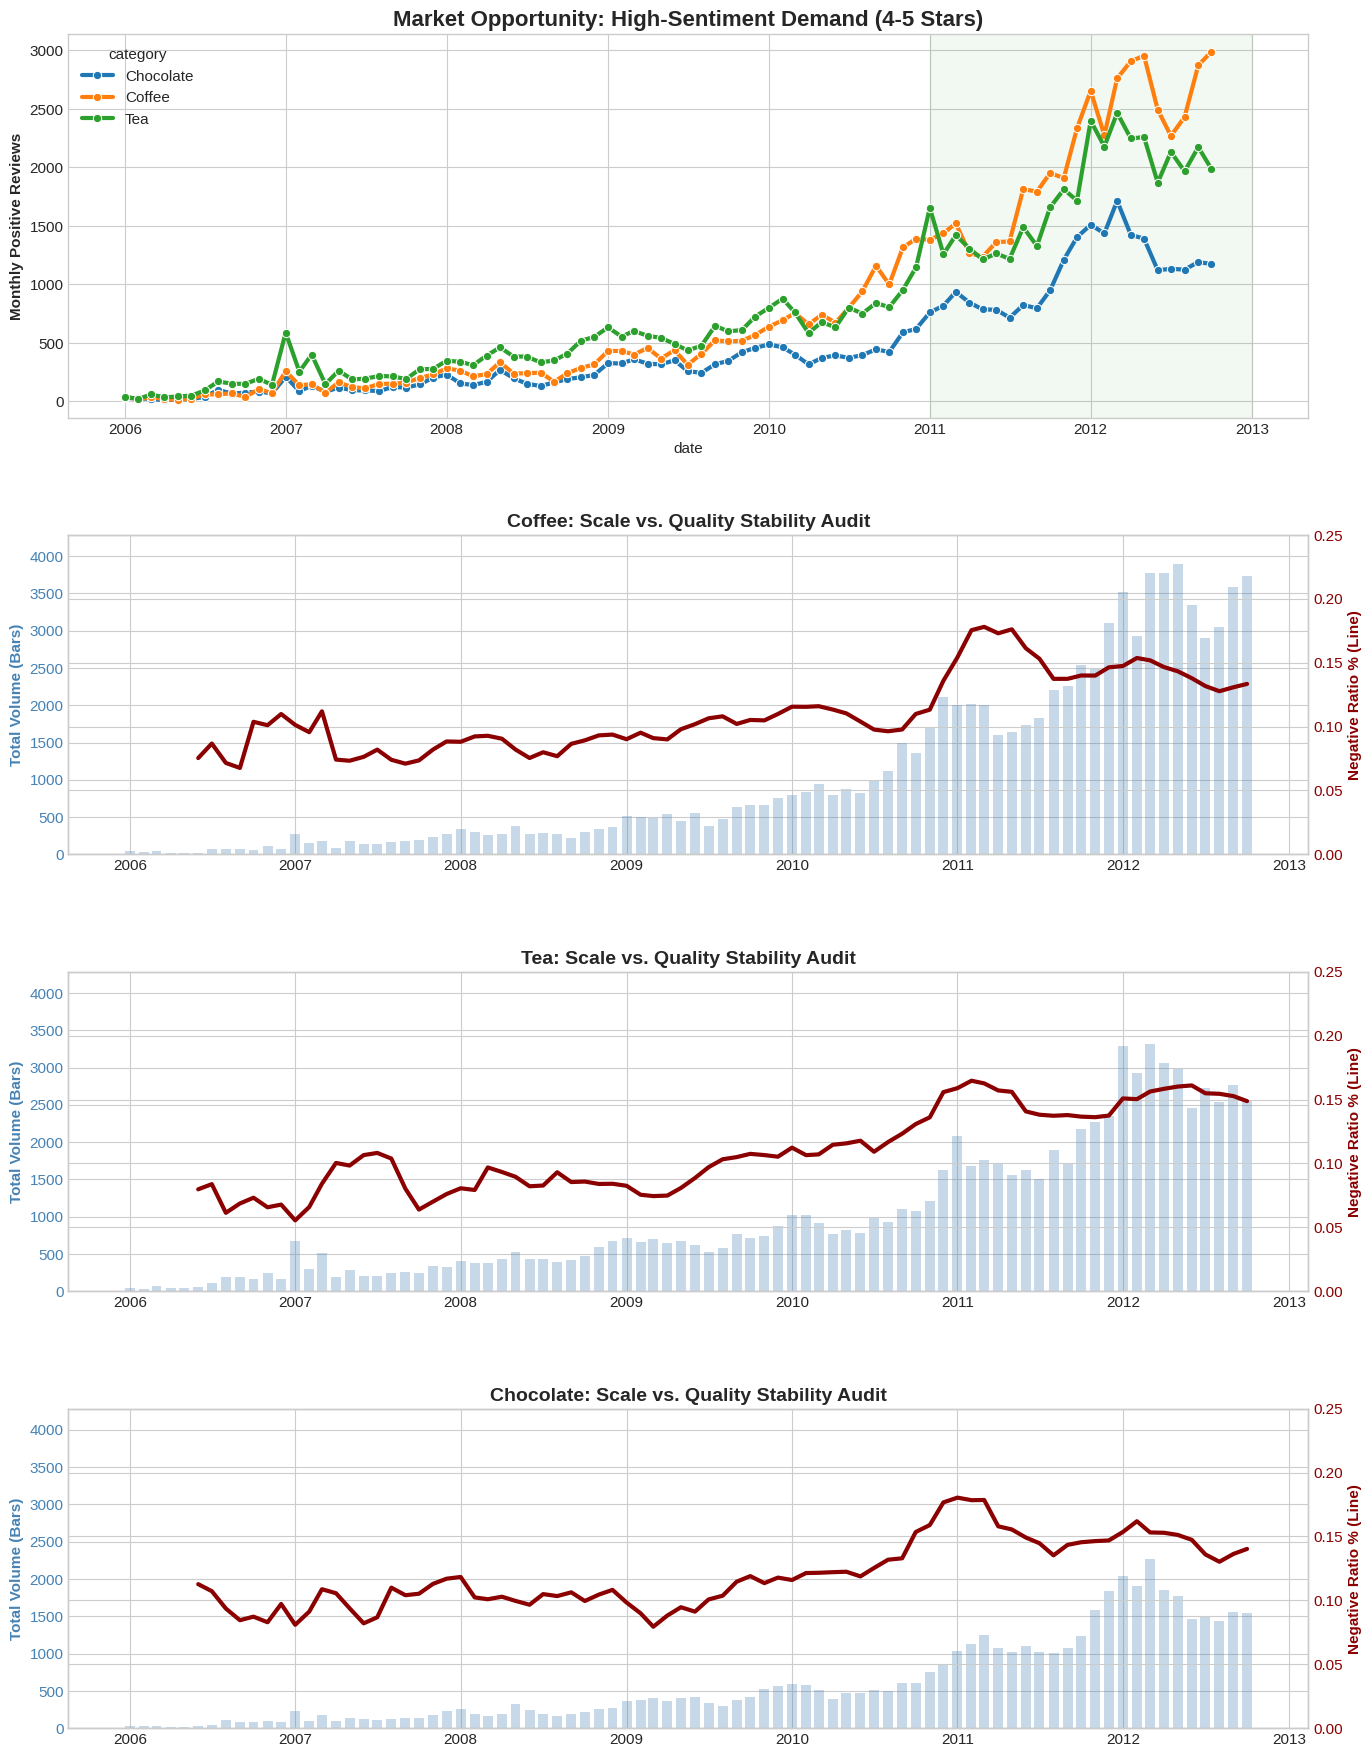

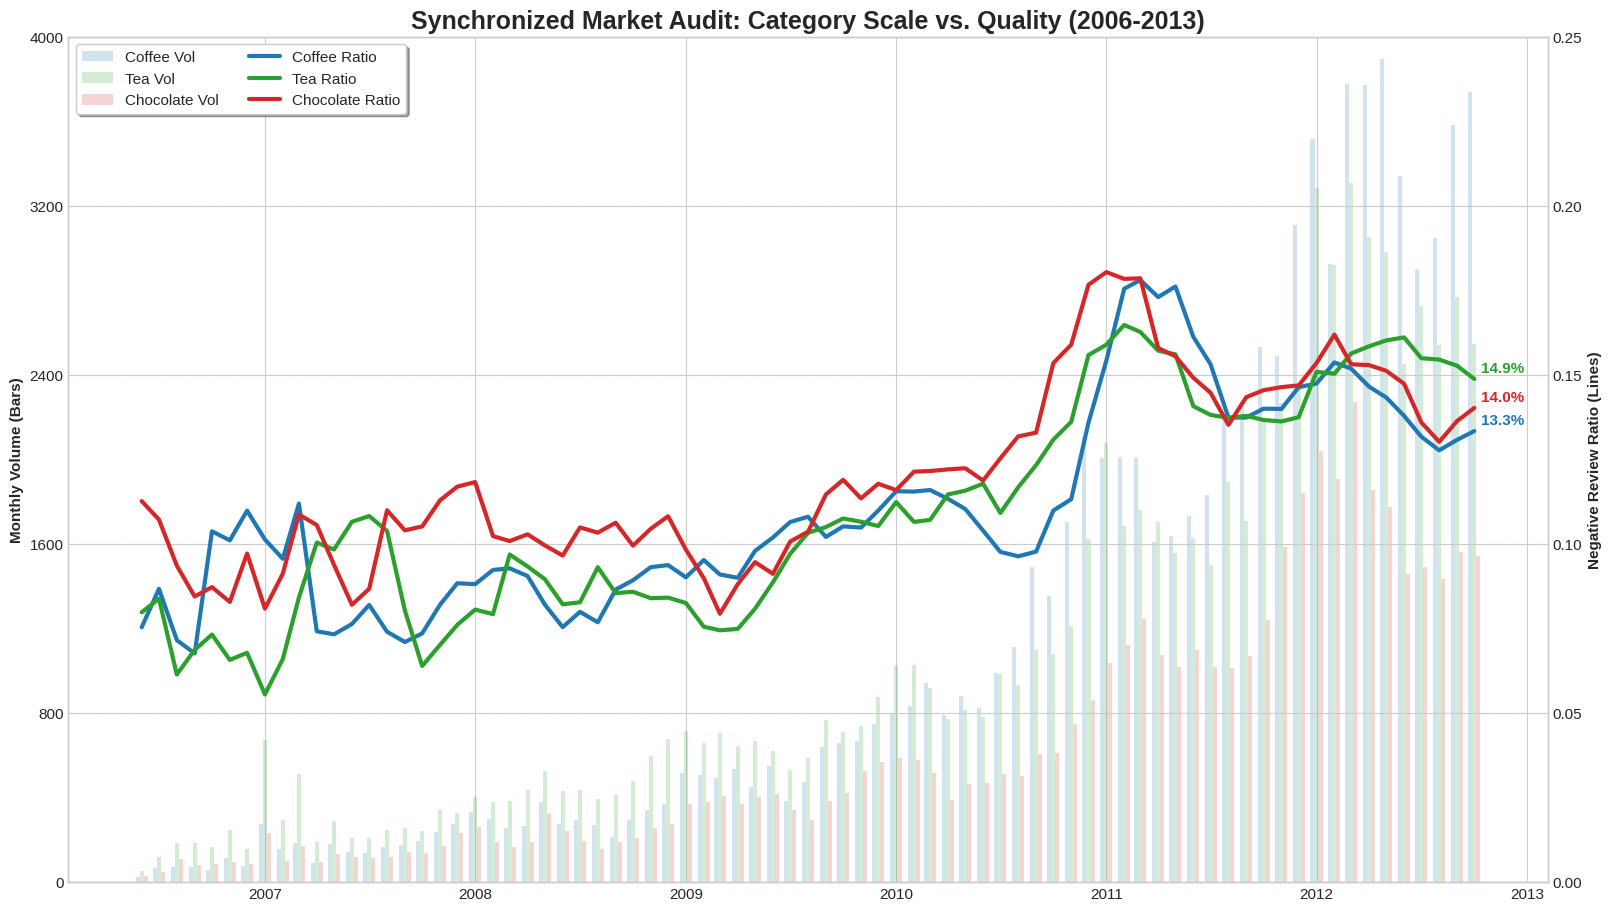

Analysis complete. Figures saved in ./thangnth_data_analysis


In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pymongo import MongoClient

# ─── 1. ENVIRONMENT SETUP ──────────────────────────────────────────────────
OUT_DIR = "./thangnht_data_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

# Visual Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white', 'axes.grid': True})

# ─── 2. DATA EXTRACTION (BEST METHOD: AGGREGATION) ─────────────────────────
def get_market_analysis_data():
    """
    Leverages MongoDB's aggregation engine to perform all calculations 
    on the server, minimizing local RAM usage and network overhead.
    """
    client = MongoClient("mongodb://localhost:27017")
    db_col = client["amazon_reviews"]["reviews"]
    
    categories = {
        "Coffee": r"coffee|espresso|roast|bean",
        "Tea": r"tea|chai|matcha|herbal",
        "Chocolate": r"chocolat|dark|cocoa|cacao"
    }
    
    data_points = []
    for label, pattern in categories.items():
        pipeline = [
            {"$match": {"Text": {"$regex": pattern, "$options": "i"}}},
            {"$addFields": {
                "dt": {"$convert": {"input": {"$multiply": ["$Time", 1000]}, "to": "date", "onError": None}}
            }},
            {"$group": {
                "_id": {"y": {"$year": "$dt"}, "m": {"$month": "$dt"}},
                "pos_vol": {"$sum": {"$cond": [{"$gte": ["$Score", 4]}, 1, 0]}},
                "neg_vol": {"$sum": {"$cond": [{"$lte": ["$Score", 2]}, 1, 0]}},
                "total_vol": {"$sum": 1}
            }},
            {"$project": {
                "_id": 0, "category": {"$literal": label},
                "year": "$_id.y", "month": "$_id.m",
                "pos_vol": 1, "neg_vol": 1, "total_vol": 1
            }}
        ]
        data_points.extend(list(db_col.aggregate(pipeline)))
    
    # DataFrame Transformation
    df = pd.DataFrame(data_points)
    df["date"] = pd.to_datetime(df[['year', 'month']].assign(DAY=1))
    df = df[df["year"] >= 2006].sort_values(["category", "date"])
    
    # Rolling 6-month average for sentiment stability
    df["neg_ratio"] = df["neg_vol"] / df["total_vol"]
    df["smoothed_ratio"] = df.groupby("category")["neg_ratio"].transform(
        lambda x: x.rolling(window=6).mean()
    )
    
    client.close()
    return df

# ─── 3. VISUALIZATION FUNCTIONS ───────────────────────────────────────────
def plot_strategic_dashboard(df):
    """Generates the multi-panel audit dashboard."""
    fig = plt.figure(figsize=(16, 22))
    gs = fig.add_gridspec(4, 1, hspace=0.35, height_ratios=[1.2, 1, 1, 1])
    
    COLOR_VOL = 'steelblue'
    COLOR_RATIO = 'darkred'

    # Figure 1: Combined High-Sentiment Demand
    ax0 = fig.add_subplot(gs[0])
    sns.lineplot(data=df, x="date", y="pos_vol", hue="category", linewidth=3, marker="o", ax=ax0)
    ax0.set_title("Market Opportunity: High-Sentiment Demand (4-5 Stars)", fontsize=16, fontweight='bold')
    ax0.set_ylabel("Monthly Positive Reviews", fontweight='bold')
    ax0.axvspan(pd.to_datetime('2011-01-01'), pd.to_datetime('2013-01-01'), color='green', alpha=0.05)

    # Standardized limits for objective auditing
    v_max, r_max = df["total_vol"].max() * 1.1, 0.25

    for i, cat in enumerate(["Coffee", "Tea", "Chocolate"]):
        ax_l = fig.add_subplot(gs[i+1])
        c_df = df[df["category"] == cat]
        
        # Scale (Bars)
        ax_l.bar(c_df["date"], c_df["total_vol"], color=COLOR_VOL, alpha=0.3, width=22)
        ax_l.set_ylim(0, v_max)
        ax_l.set_ylabel("Total Volume (Bars)", color=COLOR_VOL, fontweight='bold')
        ax_l.tick_params(axis='y', labelcolor=COLOR_VOL)
        
        # Quality (Line)
        ax_r = ax_l.twinx()
        ax_r.plot(c_df["date"], c_df["smoothed_ratio"], color=COLOR_RATIO, linewidth=3)
        ax_r.set_ylim(0, r_max)
        ax_r.set_ylabel("Negative Ratio % (Line)", color=COLOR_RATIO, fontweight='bold')
        ax_r.tick_params(axis='y', labelcolor=COLOR_RATIO)
        
        ax_l.set_title(f"{cat}: Scale vs. Quality Stability Audit", fontsize=14, fontweight='bold')
        ax_l.xaxis.set_major_locator(mdates.YearLocator())
        ax_l.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.savefig(f"{OUT_DIR}/strategic_expansion_dashboard.png", dpi=300)
    plt.show()

def plot_synchronized_audit(df):
    """Generates the unified, color-matched comparative audit."""
    fig, ax_v = plt.subplots(figsize=(16, 9), constrained_layout=True)
    ax_r = ax_v.twinx()
    
    colors = {"Coffee": "#1f77b4", "Tea": "#2ca02c", "Chocolate": "#d62728"}
    v_max, r_max = 4000, 0.25
    
    # Aligning ticks for grid clarity
    ax_v.set_ylim(0, v_max)
    ax_r.set_ylim(0, r_max)
    ax_v.set_yticks(np.linspace(0, v_max, 6))
    ax_r.set_yticks(np.linspace(0, r_max, 6))

    offsets = {"Coffee": -7, "Tea": 0, "Chocolate": 7}
    for cat, color in colors.items():
        c_df = df[df["category"] == cat].dropna(subset=["smoothed_ratio"])
        
        ax_v.bar(c_df["date"] + pd.Timedelta(days=offsets[cat]), 
                 c_df["total_vol"], width=7, color=color, alpha=0.2, label=f"{cat} Vol")
        
        ax_r.plot(c_df["date"], c_df["smoothed_ratio"], 
                  color=color, linewidth=3, label=f"{cat} Ratio")
        
        if not c_df.empty:
            last = c_df.iloc[-1]
            ax_r.annotate(f"{last['smoothed_ratio']:.1%}", 
                          xy=(last['date'], last['smoothed_ratio']),
                          textcoords="offset points", xytext=(5, 5),
                          color=color, fontweight='bold')

    plt.title("Synchronized Market Audit: Category Scale vs. Quality (2006-2013)", fontsize=18, fontweight='bold')
    ax_v.set_ylabel("Monthly Volume (Bars)", fontweight='bold')
    ax_r.set_ylabel("Negative Review Ratio (Lines)", fontweight='bold')
    ax_v.xaxis.set_major_locator(mdates.YearLocator())
    ax_v.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax_v.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    h1, l1 = ax_v.get_legend_handles_labels()
    h2, l2 = ax_r.get_legend_handles_labels()
    ax_v.legend(h1 + h2, l1 + l2, loc='upper left', ncol=2, frameon=True, shadow=True)

    plt.savefig(f"{OUT_DIR}/synchronized_market_audit.png", dpi=300)
    plt.show()

# ─── 4. EXECUTION ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    market_df = get_market_analysis_data()
    plot_strategic_dashboard(market_df)
    plot_synchronized_audit(market_df)
    print(f"Analysis complete. Figures saved in {OUT_DIR}")